In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
from IPython.display import display, clear_output
import sys
from os.path import join

project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    

from src.mnist.mnist_handle import MnistDataloader
from src.classification.neural_classification import NeuralClassifier
import src.utils.function_collections as fc

rng = np.random.default_rng(2000)

input_path = '../src/mnist/data/'
training_images_filepath = join(
    input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(
    input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(
    input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(
    input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

In [2]:
mnist_dataloader = MnistDataloader(
    training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()

x_train_array = np.array(x_train)
x_train_array = x_train_array.reshape(x_train_array.shape[0], -1) / 255
y_train_array = np.array(y_train)
x_test_array = np.array(x_test) / 255
x_test_array = x_test_array.reshape(x_test_array.shape[0], -1)
y_test_array = np.array(y_test)

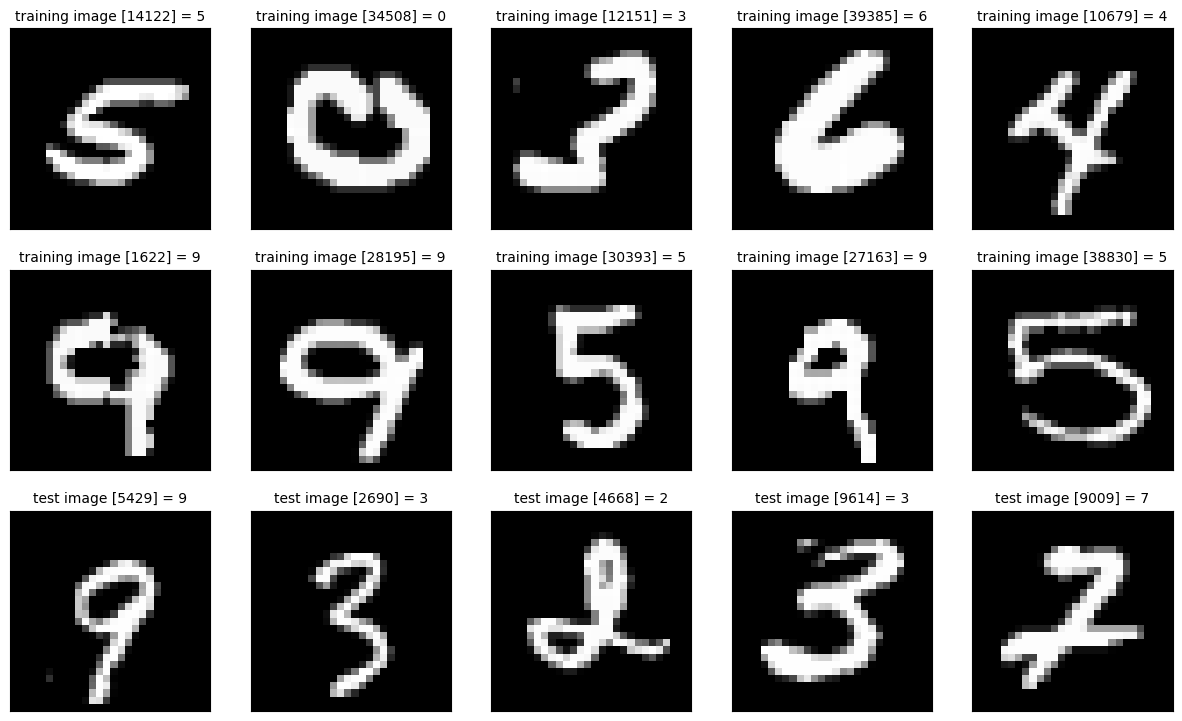

In [3]:
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(15, 12))
    index = 1
    for x in zip(images, title_texts):
        image = x[0]
        title_text = x[1]
        plt.subplot(rows, cols, index)
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize=10)
        plt.yticks([])
        plt.xticks([])
        index += 1


images_2_show = []
titles_2_show = []
r = rng.integers(0, 60000, size=10)
for i in r:
    images_2_show.append(x_train[i])
    titles_2_show.append(
        'training image [' + str(i) + '] = ' + str(y_train[i]))

r = rng.integers(0, 10000, size=5)
for i in r:
    images_2_show.append(x_test[i])
    titles_2_show.append('test image [' + str(i) + '] = ' + str(y_test[i]))

show_images(images_2_show, titles_2_show)

In [4]:
classify_activation_func = fc.leaky_relu
input_dim = x_train_array.shape[1]
num_classes = 10
classify_nn = NeuralClassifier(input_dim, 
                               num_classes, 
                               [1500, 1500, 1500],
                               classify_activation_func)
classify_training_losses, classify_validation_losses = classify_nn.train_model_with_labels(
    x_train_array, y_train_array, 20, 500, 0.001, 0.1)

Accuracy: 0.9724, Test Loss: 0.1760


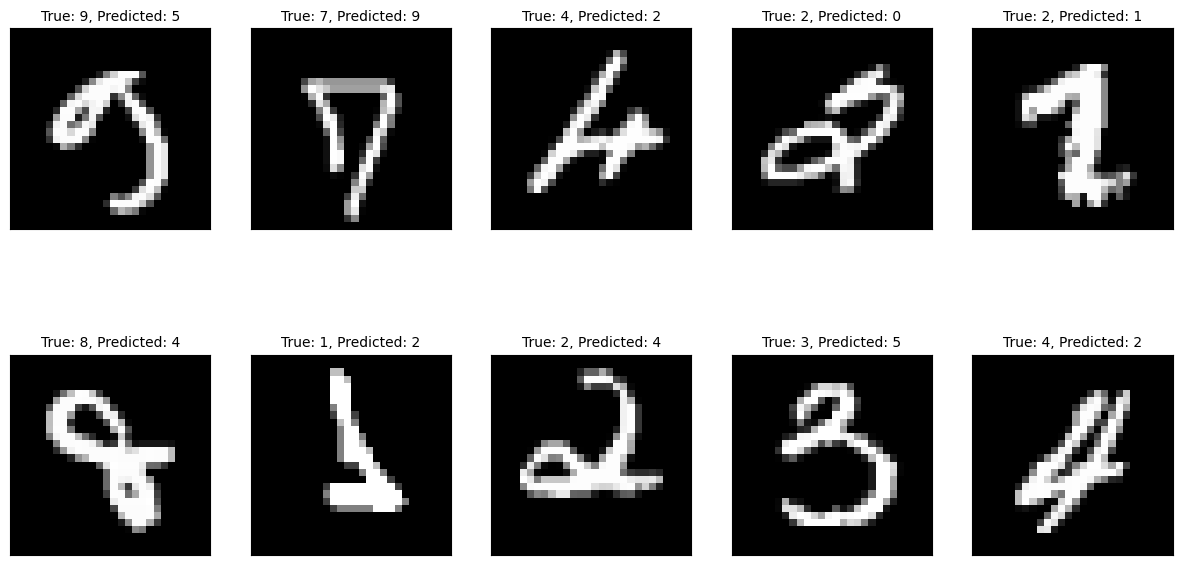

In [5]:
#Testing metrics
accuracy = classify_nn.accuracy(x_test_array, y_test_array)
y_test_array_distribution = classify_nn._label_to_distribution(
    y_test_array)
test_loss = classify_nn.compute_loss_by_input(
    y_test_array_distribution, x_test_array)
print(f"Accuracy: {accuracy:.4f}, Test Loss: {test_loss:.4f}")

#incorrect classification instances
y_pred = classify_nn.predict_label(x_test_array)
incorrect_indices = np.nonzero(y_pred != y_test_array)[0]
incorrect_x = x_test_array[incorrect_indices] * 255
incorrect_y = y_test_array[incorrect_indices]
incorrect_pred = y_pred[incorrect_indices]

show_images_3 = []
titles_3 = []
r = rng.integers(0, len(incorrect_indices), 10)
for i in r:
    show_images_3.append(incorrect_x[i].reshape(28, 28))
    titles_3.append(f"True: {incorrect_y[i]}, Predicted: {incorrect_pred[i]}")
show_images(show_images_3, titles_3)

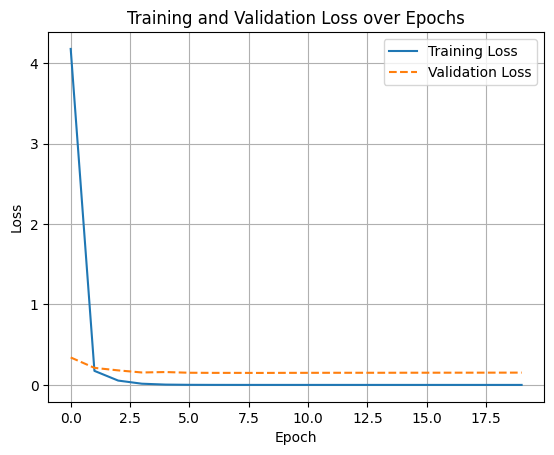

In [6]:
# plot the loss
plt.plot(classify_training_losses, label='Training Loss')
plt.plot(classify_validation_losses, label='Validation Loss', linestyle='--')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)